In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

sequence_length = 500 # 模型查看的历史窗口大小
prediction_horizon = 1 # 预测的未来窗口大小
threshold = 0.5

directory = "../datas/test" #设置数据目录
all_items = os.listdir(directory)  #列出目录下所有文件
csv_files = [os.path.join(directory, item) for item in all_items if item.endswith('.csv') and os.path.isfile(os.path.join(directory, item))]  #筛选出CSV文件 
Sample_size = len(csv_files)  #获取样本数量

sequences_data = [] #创建一个空列表，用于存储所有序列的数据
scalers = {} #创建一个空字典，用于存储每个序列对应的标准化器
base_features = ['Voltage', 'Current']
features = ['cumulative_power']

index = 0
for file in csv_files:
    df = pd.read_csv(file)
    df['impedance'] = df['Voltage'] * 1000 / df['Current'].replace(0, np.nan)
    df['power'] = df['Voltage'] * (df['Current'] / 1000)
    df['cumulative_power'] = (df['power']/1000).cumsum()
    #数据预处理 添加阻抗变化率特征
    df['impedance_diff'] = df['impedance'].diff().fillna(0) #添加一阶差分
    df['impedance_rolling_mean'] = df['impedance'].rolling(window=20, min_periods=1).mean() #滚动均值
    df['impedance_rolling_std'] = df['impedance'].rolling(window=20, min_periods=1).std()  #滚动标准差
    df['impedance_slope_10'] = df['impedance'].diff(10) / 10  #过去 10 个时间点的平均变化率。
    df['impedance_slope_10'] = df['impedance_slope_10'].fillna(0) # 将该列中的所有缺失值（NaN）填充为数字0
    df = df.ffill().bfill()  #缺失值处理先用前向填充，再用后向填充
    #数据预处理 数值归一化
    scaler = StandardScaler() #为当前序列创建一个新的StandardScaler实例
    df.loc[:, features] = scaler.fit_transform(df.loc[:, features]) #对当前序列的指定特征列进行拟合和转换
    scalers[index] = scaler #将当前序列的标准化器保存到字典中，键为序列ID
    index = index+1
    sequences_data.append(df[features + ['Action']].values) #将当前序列的数组数据添加到结果列表中

class MultiSequenceDataset(Dataset):
    #实例化后初始调用
    def __init__(self, sequences_data, sequence_length=100, prediction_horizon=50): 
        self.sequences_data = sequences_data # 输入数据
        self.sequence_length = sequence_length # 模型查看的历史窗口大小
        self.prediction_horizon = prediction_horizon # 预测的未来窗口大小
        self.samples = [] #创建一个空列表
        # for seq_data in sequences_data: #遍历列表里每一条训练数据数组（多维序列）
        n_samples = len(sequences_data) - sequence_length - prediction_horizon + 1 #计算可以生成多少个有效样本：
        for i in range(n_samples): #将n_samples个一个元组 (seq_data, i) 添加到 self.samples 列表中。
            self.samples.append((sequences_data, i)) # 生成待截取序列和开始截取的位置列表
        
    #DataLoader 会自动调用它来知道需要加载多少个样本。
    def __len__(self): 
        return len(self.samples)    #返回数据集中样本的总数，即 self.samples 列表的长度。

    #DataLoader 迭代时，会自动调用它来获取一个样本（特征和标签）。
    def __getitem__(self, idx): 
        seq_data, start_idx = self.samples[idx] #从 self.samples 列表中取出第 idx 个样本对应的原始序列 seq_data 和起始索引 start_idx。
        x = seq_data[start_idx:start_idx + self.sequence_length, :-1]#从 start_idx 开始，截取长度为 sequence_length 的连续时间步。[:, :-1] 表示取所有这些行（时间步），但只取最后一列之前的所有列。
        y_start = start_idx + self.sequence_length #输入序列 x 结束后的下一个时间点。
        y_end = y_start + self.prediction_horizon #y_start 之后的 prediction_horizon 个时间点
        y_window = seq_data[y_start:y_end, -1] # 截取了从 y_start 到 y_end 这个未来窗口内的最后一列，也就是标签列。y_window 是一个一维数组。
        y = 1 if np.any(y_window == 1) else 0
        return torch.FloatTensor(x), torch.FloatTensor([y])

print(f'检索到{Sample_size}个样本')
print(f"原始特征数量: {len(base_features)}")
print(f"扩展后特征数量: {len(features)}")
print(f"序列数量: {len(sequences_data)}")

检索到10个样本
原始特征数量: 2
扩展后特征数量: 1
序列数量: 10


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm import tqdm

model_name = 'LSTM'
# 定义RNN模型（必须与训练时相同的结构）
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.rnn = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, output_size),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, (hn, cn) = self.rnn(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 模型参数（必须与训练时相同）
input_size = len(features)
hidden_size = 128
num_layers = 2
output_size = 1

# 加载训练好的模型
model = RNNModel(input_size, hidden_size, num_layers, output_size).to(device)
model.load_state_dict(torch.load('Model_LSTM.pkl', map_location=device))
print("模型加载成功！")

Using device: cuda
模型加载成功！


In [3]:
# 评估模型
def evaluate_model(model, test_loader, device, threshold):
    model.eval()
    y_pred = []
    y_prob = []
    y_true = []
    
    with torch.no_grad():
        for batch_x, batch_y in tqdm(test_loader, desc="已完成", ncols=60):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # 前向传播
            outputs = model(batch_x)
            probabilities = outputs.cpu().numpy()
            predictions = (outputs > threshold).float().cpu().numpy()
            
            y_prob.extend(probabilities)
            y_pred.extend(predictions)
            y_true.extend(batch_y.cpu().numpy())
    
    # 转换为numpy数组
    y_prob = np.array(y_prob).flatten()
    y_pred = np.array(y_pred).flatten()
    y_true = np.array(y_true).flatten()
    
    return y_prob, y_pred, y_true

LSTM开始模型评估...


已完成: 100%|████████████| 101/101 [00:00<00:00, 161.07it/s]


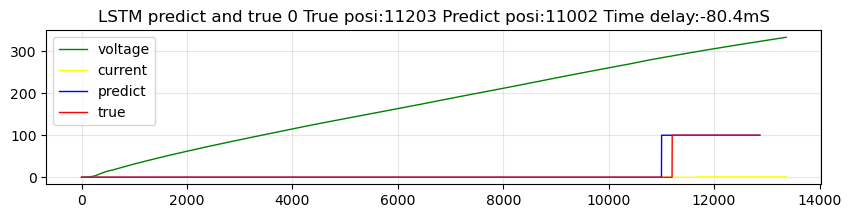

已完成: 100%|██████████████| 93/93 [00:00<00:00, 190.83it/s]


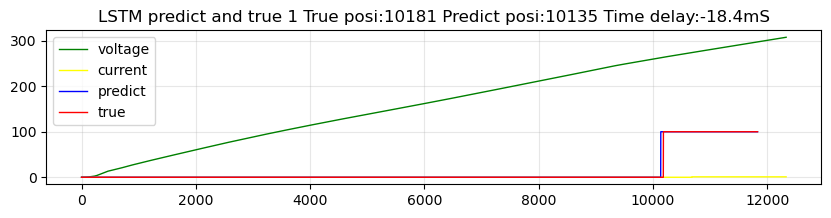

已完成: 100%|██████████████| 86/86 [00:00<00:00, 192.53it/s]


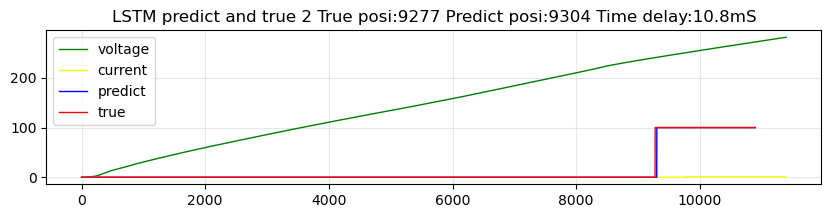

已完成: 100%|████████████| 106/106 [00:00<00:00, 191.85it/s]


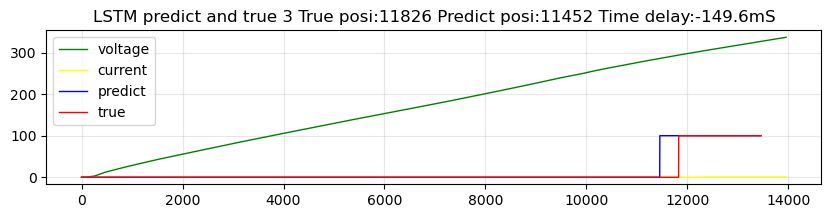

已完成: 100%|██████████████| 70/70 [00:00<00:00, 191.35it/s]


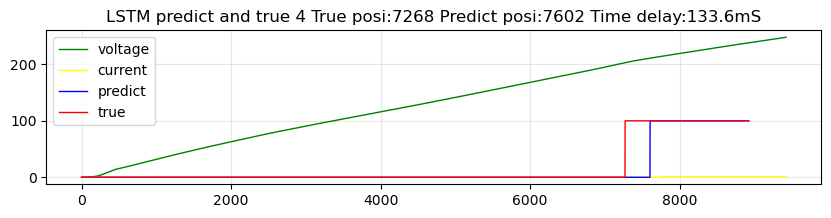

已完成: 100%|██████████████| 92/92 [00:00<00:00, 191.48it/s]


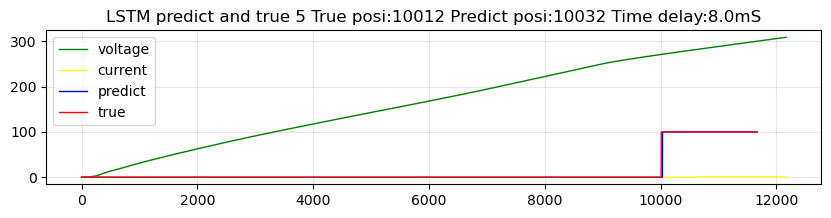

已完成: 100%|████████████| 101/101 [00:00<00:00, 191.04it/s]


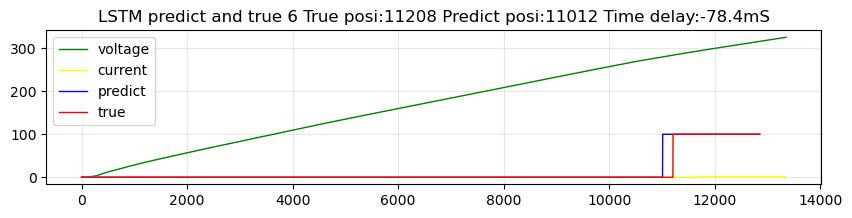

已完成: 100%|████████████| 102/102 [00:00<00:00, 190.53it/s]


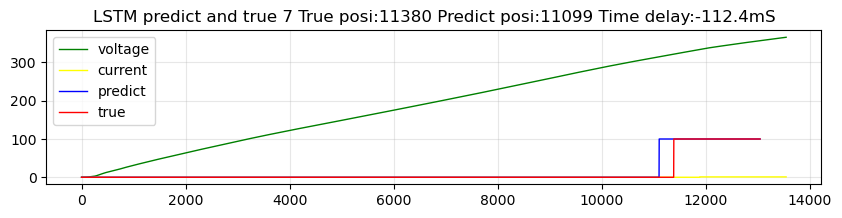

已完成: 100%|██████████████| 76/76 [00:00<00:00, 190.47it/s]


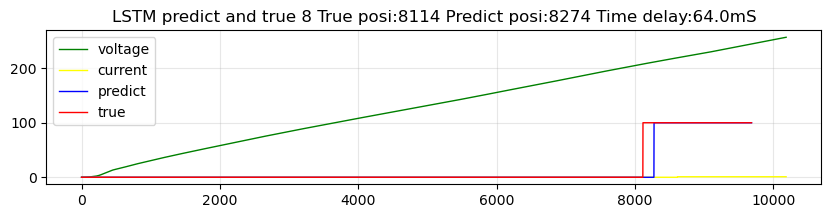

已完成: 100%|██████████████| 91/91 [00:00<00:00, 191.41it/s]


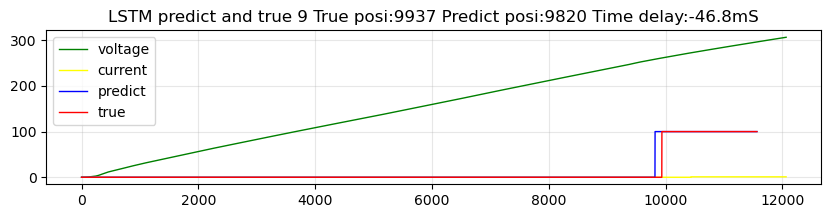

LSTM模型评估完成
完成时间20251216_041008
结果保存在Test_results_LSTM


In [4]:
import matplotlib.pyplot as plt
import time
from datetime import datetime

print(f'{model_name}开始模型评估...')
delay_result = []
test_sequences = sequences_data

for i in range(Sample_size):
    test_dataset = MultiSequenceDataset(test_sequences[i], sequence_length, prediction_horizon)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    epoch_start_time = time.time()
    probabilities, predictions, targets = evaluate_model(model, test_loader, device,threshold)
    epoch_time = time.time() - epoch_start_time

    # first_one_true = 0
    # first_one_predict = 0
    first_one_true = np.argmax(targets == 1) #找到第一个1的位置
    if targets[first_one_true] == 1:  # 确保确实找到了1
        targets[first_one_true:] = 100
        
    first_one_predict = np.argmax(predictions == 1) #找到第一个1的位置
    if predictions[first_one_predict] == 1:  # 确保确实找到了1
        predictions[first_one_predict:] = 100

    sequence = test_sequences[i]
    
    # 分离特征和标签
    sequence_features = sequence[:, :-1]
    sequence_labels = sequence[:, -1:]
    
    # 使用对应的scaler
    scaler = scalers[i]
    recovered_features = scaler.inverse_transform(sequence_features)
    
    # 重新组合
    recovered_sequence = np.column_stack((recovered_features, sequence_labels))
    
    voltage = recovered_sequence[:, 0]
    current = recovered_sequence[:, 1]
    
    # test = recovered_sequence[:, 5]
    # test [:7000] = 0
    # old_predict = np.zeros(recovered_sequence.shape[0])
    # first_old_predict = np.argmax(abs(test) > 50)
    # if abs(test[first_old_predict]) > 50:  # 确保确实找到了
    #     old_predict[first_old_predict:] = 100
    
    plt.figure(figsize=(10, 2))
    plt.plot(voltage, label='voltage', color='green', linewidth=1)
    plt.plot(current, label='current', color='yellow', linewidth=1)
    # plt.plot(test, label='test', color='orange', linewidth=1)
    # plt.plot(old_predict, label='old_predict', color='orange', linewidth=1)
    plt.plot(predictions, label='predict', color='blue', linewidth=1)
    plt.plot(targets, label='true', color='red', linewidth=1)
    Delay_time = (first_one_predict - first_one_true)*0.4
    plt.title(f'{model_name} predict and true {i} True posi:{first_one_true} Predict posi:{first_one_predict} Time delay:{Delay_time:.1f}mS')
    plt.legend()  # 显示图例
    plt.grid(True, alpha=0.3)
    save_dir = f'Test_results_{model_name}'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, f'model_evaluation{i}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    delay_result.append({
        'index':i,
        'True':first_one_true,
        # 'diff':first_old_predict,
        f'{model_name}':first_one_predict,
        f'{model_name} Delay':Delay_time,
        f'{model_name} perdict_time mS':epoch_time * 1000 / len(test_sequences[i])
    })
    # print(len(test_sequences[i]))

print(f'{model_name}模型评估完成')
df = pd.DataFrame(delay_result)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"完成时间{timestamp}")
print(f'结果保存在{save_dir}')

In [5]:
print(df[f'{model_name} Delay'].to_string(index=False))

 -80.4
 -18.4
  10.8
-149.6
 133.6
   8.0
 -78.4
-112.4
  64.0
 -46.8
